### Load Dataset

In [ ]:
!pip install opencv-python matplotlib

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

sys.path.append(str(ROOT))

In [27]:
import os
from glob import glob

DATASET_DIR = os.path.join('..', 'dataset', 'raw')
images = glob(os.path.join(DATASET_DIR, 'images', "*"))

img_ann = []

for file in images:
    f = file.split('\\')[-1]
    annotation_file = f.split('.')[0]
    annotation_file_name = annotation_file + '.txt'
    ann = os.path.join(DATASET_DIR, 'annotations', annotation_file_name)
    img_ann.append((file, ann))

In [36]:
i = []
for idx, (img, ann) in enumerate(img_ann):
    with open(ann, "r") as f:
        for lines in f:
            values = lines.strip().split(",")
            cls = int(values[5])

            if(cls == 8):
                print(img)
                i.append(idx)

..\dataset\raw\images\0000002_00005_d_0000014.jpg
..\dataset\raw\images\0000002_00005_d_0000014.jpg
..\dataset\raw\images\0000002_00448_d_0000015.jpg
..\dataset\raw\images\0000002_00448_d_0000015.jpg
..\dataset\raw\images\0000002_00448_d_0000015.jpg
..\dataset\raw\images\0000013_00465_d_0000067.jpg
..\dataset\raw\images\0000016_00420_d_0000068.jpg
..\dataset\raw\images\0000016_01352_d_0000069.jpg
..\dataset\raw\images\0000042_01000_d_0000074.jpg
..\dataset\raw\images\0000042_01000_d_0000074.jpg
..\dataset\raw\images\0000042_01000_d_0000074.jpg
..\dataset\raw\images\0000042_02231_d_0000075.jpg
..\dataset\raw\images\0000042_02421_d_0000076.jpg
..\dataset\raw\images\0000042_02421_d_0000076.jpg
..\dataset\raw\images\0000042_02421_d_0000076.jpg
..\dataset\raw\images\0000042_02421_d_0000076.jpg
..\dataset\raw\images\0000042_02421_d_0000076.jpg
..\dataset\raw\images\0000045_00000_d_0000083.jpg
..\dataset\raw\images\0000045_00000_d_0000083.jpg
..\dataset\raw\images\0000045_00000_d_0000083.jpg


In [37]:
i

[0,
 0,
 1,
 1,
 1,
 16,
 17,
 18,
 35,
 35,
 35,
 36,
 37,
 37,
 37,
 37,
 37,
 39,
 39,
 39,
 39,
 40,
 41,
 41,
 42,
 42,
 42,
 42,
 42,
 43,
 43,
 46,
 46,
 46,
 51,
 52,
 52,
 52,
 53,
 53,
 53,
 53,
 53,
 54,
 54,
 54,
 54,
 54,
 55,
 60,
 61,
 85,
 86,
 88,
 90,
 91,
 101,
 120,
 122,
 122,
 131,
 163,
 163,
 174,
 175,
 200,
 201,
 204,
 205,
 209,
 210,
 221,
 229,
 229,
 229,
 229,
 229,
 229,
 231,
 232,
 240,
 240,
 240,
 254,
 254,
 255,
 279,
 279,
 279,
 280,
 280,
 280,
 281,
 281,
 281,
 281,
 281,
 281,
 282,
 282,
 282,
 282,
 282,
 282,
 282,
 282,
 282,
 283,
 283,
 283,
 283,
 283,
 283,
 284,
 284,
 284,
 284,
 284,
 284,
 284,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 285,
 286,
 286,
 286,
 286,
 286,
 286,
 286,
 286,
 286,
 286,
 286,
 286,
 286,
 286,
 287,
 287,
 287,
 287,
 287,
 287,
 287,
 287,
 288,
 288,
 288,
 289,
 289,
 289,
 289,
 289,
 289,
 289,
 289,
 289,
 289,
 289,
 289,
 289,
 289,
 289,

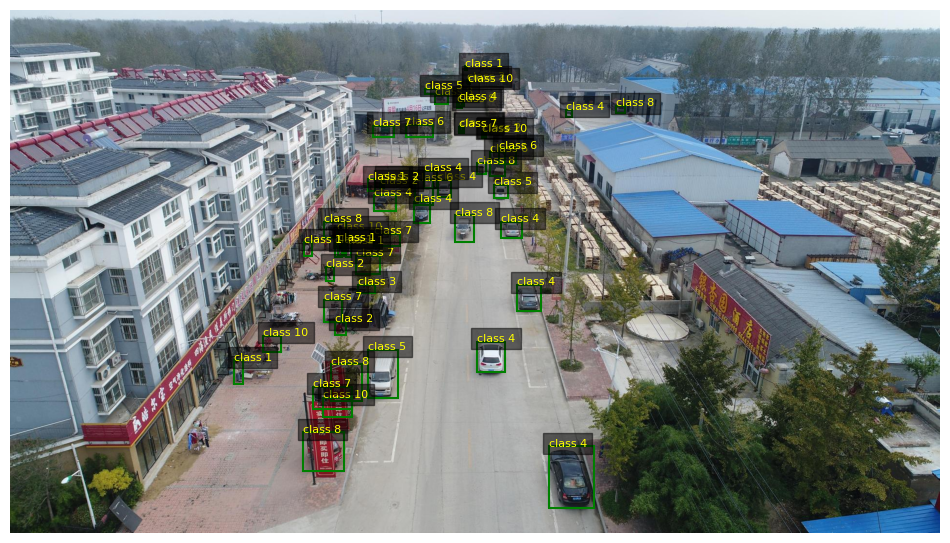

In [ ]:
import matplotlib.pyplot as plt
import cv2


img, ann = img_ann[1413]

boxes = []


img = cv2.imread(img)
if img is None:
    raise FileNotFoundError("Image not found")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

with open(ann, "r") as f:
    for line in f:
        values = line.strip().split(",")

        x = int(values[0])
        y = int(values[1])
        w = int(values[2])
        h = int(values[3])
        cls = int(values[5])
        if cls == 0:
            continue

        boxes.append((x, y, w, h, cls))

plt.figure(figsize=(12,8))
plt.imshow(img)

ax = plt.gca()

for x, y, w, h, cls in boxes:

        rect = plt.Rectangle(
            (x, y),
            w,
            h,
            linewidth=1.5,
            edgecolor="green",
            facecolor="none"
        )

        ax.add_patch(rect)

        plt.text(
            x,
            y,
            f"class {cls}",
            color="yellow",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.5)
        )


plt.axis("off")
plt.show()

In [4]:
from src.datasets.dataset import DroneDetectionDataset

ds = DroneDetectionDataset(DATASET_DIR)
len(ds)

image, target = ds[0]

print(image.shape)
print(target)

(540, 960, 3)
{'boxes': tensor([[708., 471., 782., 504.],
        [639., 425., 700., 471.],
        [594., 399., 658., 450.],
        [562., 390., 623., 428.],
        [540., 372., 605., 405.],
        [514., 333., 582., 368.],
        [501., 317., 565., 348.],
        [501., 299., 546., 327.],
        [489., 284., 537., 311.],
        [463., 262., 511., 291.],
        [458., 252., 507., 274.],
        [448., 242., 493., 262.],
        [442., 230., 491., 249.],
        [439., 214., 484., 235.],
        [429., 208., 471., 227.],
        [420., 199., 463., 219.],
        [398., 188., 439., 206.],
        [ 46., 391.,  60., 417.],
        [421., 433., 495., 477.],
        [369., 346., 433., 380.],
        [398., 410., 470., 456.],
        [394., 393., 464., 429.],
        [377., 364., 448., 402.],
        [357., 312., 415., 343.],
        [359., 298., 413., 320.],
        [348., 283., 391., 311.],
        [345., 271., 397., 290.],
        [340., 260., 400., 278.],
        [340., 250., 392

In [3]:
from src.datasets.dataloader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(
    "../dataset/raw",
    batch_size=4
)

print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))

4529
1294
648


In [4]:
images, targets = next(iter(train_loader))

print(type(images))
print(len(images))

print(type(targets))
print(len(targets))

print(images[0].shape)
print(targets[0])

<class 'list'>
4
<class 'list'>
4
(788, 1400, 3)
{'boxes': tensor([[ 809.,  379.,  839.,  436.],
        [ 891.,  482.,  914.,  517.],
        [ 953.,  601.,  976.,  629.],
        [ 855.,  720.,  876.,  747.],
        [ 997.,  606., 1018.,  634.],
        [ 928.,  661.,  953.,  686.],
        [ 877.,  643.,  903.,  667.],
        [ 805.,  740.,  824.,  764.],
        [ 763.,  708.,  787.,  730.],
        [ 719.,  745.,  743.,  770.],
        [ 780.,  738.,  796.,  761.],
        [ 845.,  630.,  873.,  659.],
        [ 823.,  633.,  839.,  665.],
        [ 891.,  608.,  919.,  638.],
        [ 925.,  586.,  939.,  617.],
        [ 804.,  606.,  836.,  649.],
        [ 825.,  617.,  836.,  645.],
        [ 930.,  570.,  953.,  601.],
        [ 124.,  215.,  163.,  257.],
        [ 116.,  382.,  159.,  411.],
        [ 345.,  136.,  370.,  186.],
        [  44.,  144.,   84.,  188.],
        [  23.,  169.,   62.,  212.],
        [1064.,  412., 1096.,  444.],
        [1075.,  456., 1112.,

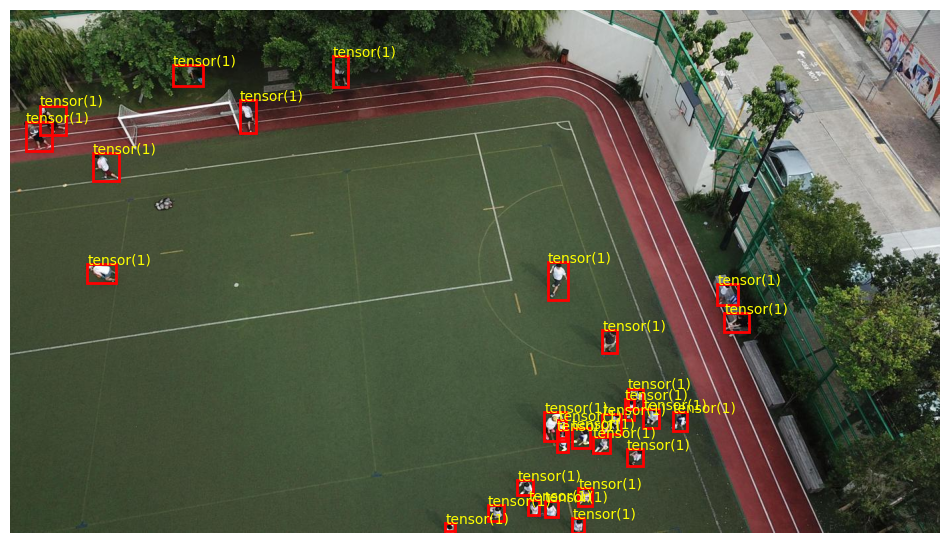

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


img = images[0]
target = targets[0]


plt.figure(figsize=(12,8))

plt.imshow(img)

ax = plt.gca()


for box, label in zip(
    target["boxes"],
    target["labels"]
):

    x1, y1, x2, y2 = box

    rect = patches.Rectangle(
        (x1, y1),
        x2-x1,
        y2-y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        str(label),
        color="yellow",
        fontsize=10
    )


plt.axis("off")
plt.show()

In [6]:
from collections import Counter

counter = Counter()

for _, target in train_loader.dataset:

    for label in target["labels"]:
        counter[int(label)] += 1


print(counter)

Counter({4: 102028, 1: 54645, 10: 20361, 2: 18905, 5: 17333, 6: 8889, 3: 7315, 9: 3899, 7: 3362, 8: 2262, 11: 1071})


In [ ]:
cls = {
    1: "pedestrian",
    2: "person", 
    3: "bicycle",
    4: "car",
    5: "van",
    6: "truck",
    7: "tuktuk",
    8: "rickshaw",
    9: "bus",
    10: "bike",    
}